<a href="https://colab.research.google.com/github/Jangam10/Telecom_dataset_EDA/blob/main/STDS_TelecomData_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
import missingno as msno

In [ ]:
import csv
df = pd.read_csv("/content/drive/MyDrive/STDS_Assignment/TeleCom_Data-1.csv",sep=";",encoding="utf-8",engine="python",quoting=csv.QUOTE_NONE) #QUOTE_NONE used for inconsistency of double quotes

print(df.head())
print(df.shape)

  "age          ""job""  ""marital""            ""education""  ""default""  \
0  "40       ""admin.""  ""married""             ""basic.6y""       ""no""   
1  "56     ""services""  ""married""          ""high.school""       ""no""   
2  "45     ""services""  ""married""             ""basic.9y""  ""unknown""   
3  "59       ""admin.""  ""married""  ""professional.course""       ""no""   
4  "41  ""blue-collar""  ""married""              ""unknown""  ""unknown""   

  ""housing"" ""loan""    ""contact"" ""month"" ""day_of_week""  ...  \
0      ""no""   ""no""  ""telephone""   ""may""         ""mon""  ...   
1      ""no""  ""yes""  ""telephone""   ""may""         ""mon""  ...   
2      ""no""   ""no""  ""telephone""   ""may""         ""mon""  ...   
3      ""no""   ""no""  ""telephone""   ""may""         ""mon""  ...   
4      ""no""   ""no""  ""telephone""   ""may""         ""mon""  ...   

   ""campaign""  ""pdays""  ""previous""     ""poutcome"" ""emp.var.rate""  \
0             1     

In [ ]:
# removing quotes from data set
df.columns = [col.strip('"') for col in df.columns] # from headers

# removal from all data other than header
for col in df.columns:
      df[col] = df[col].apply(lambda x: x.strip('"') if isinstance(x, str) else x)
print(df.head())
print(df.shape)

# 41180 rows and 21 columns

  age          job  marital            education  default housing loan  \
0  40       admin.  married             basic.6y       no      no   no   
1  56     services  married          high.school       no      no  yes   
2  45     services  married             basic.9y  unknown      no   no   
3  59       admin.  married  professional.course       no      no   no   
4  41  blue-collar  married              unknown  unknown      no   no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0  telephone   may         mon  ...         1    999         0  nonexistent   
1  telephone   may         mon  ...         1    999         0  nonexistent   
2  telephone   may         mon  ...         1    999         0  nonexistent   
3  telephone   may         mon  ...         1    999         0  nonexistent   
4  telephone   may         mon  ...         1    999         0  nonexistent   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
0   

In [ ]:
# Improving readability of dataset

pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.max_rows', 20)       # limit rows shown
pd.set_option('display.width', 1000)        # widen display
pd.set_option('display.colheader_justify', 'center')  # center headers

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# Checking data types and corresponding not null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41180 entries, 0 to 41179
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41180 non-null  object 
 1   job             41180 non-null  object 
 2   marital         41180 non-null  object 
 3   education       41180 non-null  object 
 4   default         41180 non-null  object 
 5   housing         41180 non-null  object 
 6   loan            41180 non-null  object 
 7   contact         41180 non-null  object 
 8   month           41180 non-null  object 
 9   day_of_week     41180 non-null  object 
 10  duration        41180 non-null  int64  
 11  campaign        41180 non-null  int64  
 12  pdays           41180 non-null  int64  
 13  previous        41180 non-null  int64  
 14  poutcome        41180 non-null  object 
 15  emp.var.rate    41180 non-null  float64
 16  cons.price.idx  41180 non-null  float64
 17  cons.conf.idx   41180 non-null 

In [ ]:
# Summary statistics of the dataset
# converting age to integer
df["age"] = pd.to_numeric(df["age"], errors="coerce").astype("Int64")
df.describe().round(2)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41180.0,41180.00,41180.00,41180.00,41180.00,41180.00,41180.00,41180.00,41180.00,41180.00
mean,40.02,258.28,2.57,962.52,0.17,0.08,93.58,-40.50,3.62,5167.05
std,10.42,259.30,2.77,186.81,0.49,1.57,0.58,4.63,1.73,72.23
min,17.0,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.0,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.0,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.0,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.0,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [ ]:
# Summary statistics of object columns
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41180,41180,41180,41180,41180,41180,41180,41180,41180,41180,41180
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24921,12166,32581,21571,33943,26140,13765,8622,35559,36542


Data Cleaning and Preparation

In [ ]:
# checking for duplicate values

print(f"The number of duplicate rows are {df.duplicated().sum()}")

duplicates = df[df.duplicated(keep=False)] # all duplicates including first occurence
print(duplicates)

# removing the duplicate rows
df.drop_duplicates(inplace=True) # inplace makes changes in dataset itself, no new dataframe
print(f"\nThe number of duplicate rows after duplicate removal are {df.duplicated().sum()}")
df.shape

# 12 rows dropped

The number of duplicate rows are 0
Empty DataFrame
Columns: [age, job, marital, education, default, housing, loan, contact, month, day_of_week, duration, campaign, pdays, previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed, y]
Index: []

The number of duplicate rows after duplicate removal are 0


(41168, 21)

In [ ]:
# checking missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

# output 0 indicates no missing values

,0


In [ ]:
# for pdays we find the maximum no. of days client not contacted as 999, so checking unique values
print("The percentage distribution for no. of days the client was last contacted is")
pd.set_option('display.max_rows', None)
print(df["pdays"].value_counts(normalize=True,dropna=False)*100.00)

# 999 days for more than 96% percent so, seems as missing data so replacing it with -1 as described in data dictionary
df["pdays"].replace(np.nan,-1,inplace=True)

df["pdays"].describe()

The percentage distribution for no. of days the client was last contacted is
pdays
-1.0     96.324815
 3.0      1.066362
 6.0      0.998348
 4.0      0.286630
 9.0      0.155461
 2.0      0.148173
 7.0      0.145744
 12.0     0.140886
 10.0     0.126312
 5.0      0.111737
 13.0     0.087447
 11.0     0.068014
 1.0      0.060727
 15.0     0.058298
 14.0     0.048581
 8.0      0.043723
 0.0      0.036436
 16.0     0.026720
 17.0     0.019433
 18.0     0.017003
 22.0     0.007287
 19.0     0.007287
 21.0     0.004858
 25.0     0.002429
 26.0     0.002429
 27.0     0.002429
 20.0     0.002429
Name: proportion, dtype: float64


,pdays
count,41168.000000
mean,-0.742081
std,1.510294
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,27.000000


In [ ]:
# I am curious about the distinct categorical variables and if cleaning needs to be performed for it.

from collections import Counter

for col in df.columns:
    if df[col].dtype == 'object':
      print(f"\nColumn: {col}")
      counts = Counter(df[col].dropna())  # drop NaN for counting
      for value, freq in counts.most_common():
          print(f"{value}: {freq}")

# Improving readability of column education by replacing dots
df["education"] = df["education"].str.replace(".", " ", regex=False)

df["education"].value_counts()


Column: job
admin.: 10419
blue-collar: 9252
technician: 6738
services: 3965
management: 2923
retired: 1716
entrepreneur: 1456
self-employed: 1421
housemaid: 1059
unemployed: 1014
student: 875
unknown: 330

Column: marital
married: 24914
single: 11564
divorced: 4610
unknown: 80

Column: education
university.degree: 12162
high.school: 9510
basic.9y: 6044
professional.course: 5238
basic.4y: 4175
basic.6y: 2291
unknown: 1730
illiterate: 18

Column: default
no: 32570
unknown: 8595
yes: 3

Column: housing
yes: 21566
no: 18612
unknown: 990

Column: loan
no: 33931
yes: 6247
unknown: 990

Column: contact
cellular: 26131
telephone: 15037

Column: month
may: 13763
jul: 7169
aug: 6176
jun: 5318
nov: 4096
apr: 2631
oct: 717
sep: 570
mar: 546
dec: 182

Column: day_of_week
thu: 8617
mon: 8507
wed: 8133
tue: 8086
fri: 7825

Column: poutcome
nonexistent: 35547
failure: 4250
success: 1371

Column: y
no: 36531
yes: 4637


,count
education,
university degree,12162
high school,9510
basic 9y,6044
professional course,5238
basic 4y,4175
basic 6y,2291
unknown,1730
illiterate,18


Exploratory Data Analysis

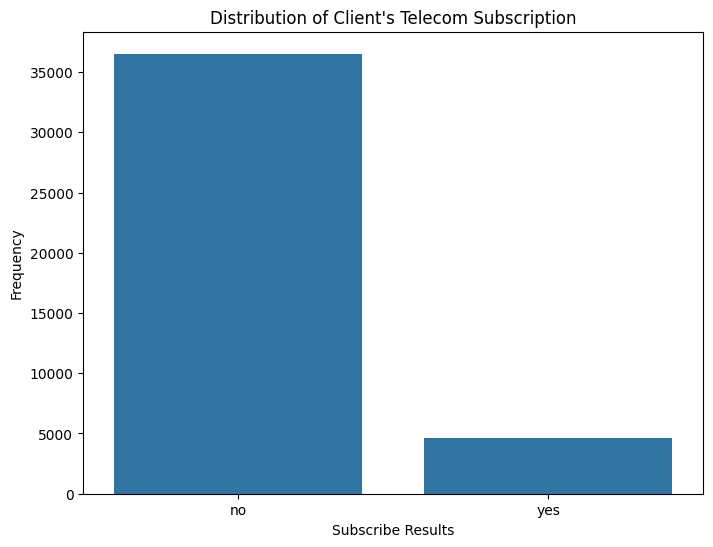

In [ ]:
# Distribution of target variable
plt.figure(figsize=(8, 6))
sns.countplot(data = df,x= "y")
plt.title("Distribution of Client's Telecom Subscription")
plt.xlabel('Subscribe Results')
plt.ylabel('Frequency')
plt.show()